## 1번 문제

1. num_1 폴더의 tsv 파일을 데이터프레임으로 불러온다. 
2. 숫자 의미를 가지지 않은 order_id는 str의 형태로 변경한다. 
3. 가장 많이 주문을 한 item_name과 그 수량을 출력한다. 
4. item당 주문 총량을 구하고 바형 그래프로 시각화하여 출력한다. 
5. item_price가 object형태의 데이터임으로 float 형태로 변경한다. 
6. 주문당 평균 계산 금액을 출력한다. 
7. 각 아이템의 가격을 출력 후 가격 분포 그래프와 가격 히스토그램을 출력한다. 
8. "Chicken Bowl"을 2개 이상 주문한 고객들의 "Chicken Bowl" 메뉴의 총 주문 수량을 출력한다. 


In [144]:
# 문제 1번
import pandas as pd
chipotle=pd.read_table(('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/prob_2/2회차/num_1/chipotle.tsv'))
chipotle

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75


In [145]:
# 문제  2. 숫자 의미를 가지지 않은 order_id는 str의 형태로 변경한다. 
for i in range(0,4622):
    chipotle['order_id'][i]=str(chipotle['order_id'][i])

chipotle

C:\Users\jangd\AppData\Local\Temp\ipykernel_22636\3024870729.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chipotle['order_id'][i]=str(chipotle['order_id'][i])


,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75


In [146]:
# 3. 가장 많이 주문을 한 item_name과 그 수량을 출력한다. 
print(chipotle.loc[chipotle['quantity'] == max(chipotle['quantity']) ,'item_name'], max(chipotle['quantity']))


3598    Chips and Fresh Tomato Salsa
Name: item_name, dtype: object 15


<BarContainer object of 50 artists>

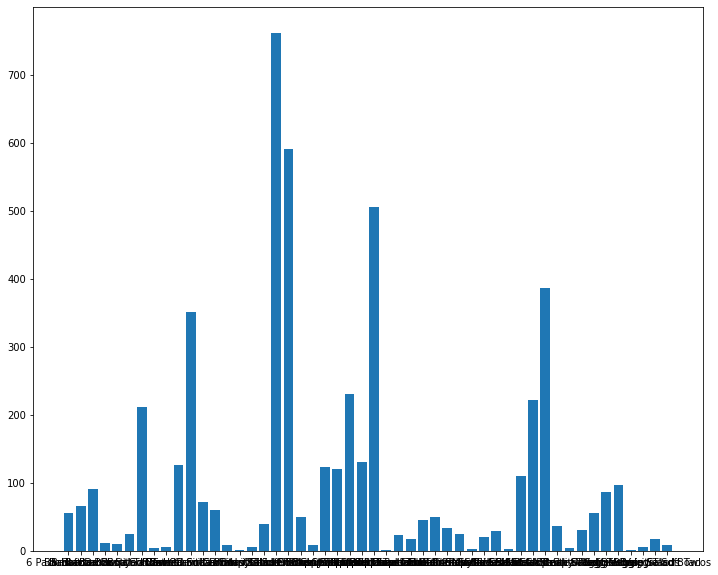

In [147]:
# 4. item당 주문 총량을 구하고 바형 그래프로 시각화하여 출력한다.
import numpy as np
import matplotlib.pyplot as plt
b = chipotle.groupby('item_name').sum('quantity')

list=[]
for i in range(0,50):
    list.append(b['quantity'][i])
    
b.index
list

plt.bar(b.index, list)


In [148]:
# 5. item_price가 object형태의 데이터임으로 float 형태로 변경한다. 

list=[]

for i in range(0,chipotle.shape[0]):    
    list.append(str(chipotle.loc[i, 'item_price']).split('$')[1])

chipotle['item_price_1']=list
chipotle['item_price_1']=chipotle['item_price_1'].astype('float')
chipotle.dtypes


order_id               object
quantity                int64
item_name              object
choice_description     object
item_price             object
item_price_1          float64
dtype: object

In [149]:
chipotle


,order_id,quantity,item_name,choice_description,item_price,item_price_1
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39,2.39
1,1,1,Izze,[Clementine],$3.39,3.39
2,1,1,Nantucket Nectar,[Apple],$3.39,3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98,16.98
...,...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75,11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75,11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25,11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75,8.75


In [150]:
# 6. 주문당 평균 계산 금액을 출력한다. 
chipotle['sum']=chipotle['item_price_1']*chipotle['quantity']
chipotle.groupby('order_id').mean()

,quantity,item_price_1,sum
order_id,,,
1,1.00,2.890000,2.890000
10,1.00,6.600000,6.600000
100,1.00,5.040000,5.040000
1000,1.00,10.250000,10.250000
1001,1.00,5.040000,5.040000
...,...,...,...
995,1.00,8.316667,8.316667
996,1.00,10.750000,10.750000
997,2.00,22.500000,45.000000


In [151]:
#7. 각 아이템의 가격을 출력 후 가격 분포 그래프와 가격 히스토그램을 출력한다. 

chipotle.groupby(['item_name', 'item_price_1']).size()
chipotle['price']=chipotle['item_price_1']/chipotle['quantity']
a=chipotle.groupby(['item_name','choice_description' ,'price']).size()
b=pd.DataFrame(a)
# chipotle
c=[]
for i in range(len(b.index)):
    c.append(b.index[i])
d=pd.DataFrame(c)
d

,0,1,2
0,6 Pack Soft Drink,[Coke],6.49
1,6 Pack Soft Drink,[Diet Coke],6.49
2,6 Pack Soft Drink,[Lemonade],6.49
3,6 Pack Soft Drink,[Nestea],6.49
4,6 Pack Soft Drink,[Sprite],6.49
...,...,...,...
1854,Veggie Soft Tacos,"[Fresh Tomato Salsa, [Black Beans, Cheese, Sou...",8.75
1855,Veggie Soft Tacos,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",11.25
1856,Veggie Soft Tacos,"[Roasted Chili Corn Salsa (Medium), [Black Bea...",8.49
1857,Veggie Soft Tacos,"[Roasted Chili Corn Salsa, [Fajita Vegetables,...",8.75


In [152]:
#8. "Chicken Bowl"을 2개 이상 주문한 고객들의 "Chicken Bowl" 메뉴의 총 주문 수량을 출력한다. 
chipotle.loc[(chipotle['item_name']=='Chicken Bowl')&(chipotle['quantity']>=2)].sum()[1]

68

## 2번 문제

1. num_2 폴더의 csv 파일을 데이터프레임으로 불러온다. 
2. 'beer_servings', 'spirit_servings', 'wine_servings', 'total_litres_of_pure_alcohol' 간의 상관관계 행렬을 구한다. 
3. 행렬 히트맵을 시각화 한다. 
4. 'beer_servings', 'spirit_servings', 'wine_servings', 'total_litres_of_pure_alcohol' 컬럼별 산점도 그래프를 표시한다. 
5. 국가별 술 소비량 대비 알콜 비율 컬럼을 추가하여 국가별 순위를 시각화하여 출력한다. 

In [153]:
# 문제 1번
import pandas as pd
drinks=pd.read_csv(('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/prob_2/2회차/num_2/drinks.csv'))
drinks

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF
...,...,...,...,...,...,...
188,Venezuela,333,100,3,7.7,SA
189,Vietnam,111,2,1,2.0,AS
190,Yemen,6,0,0,0.1,AS
191,Zambia,32,19,4,2.5,AF


In [154]:
#2. 'beer_servings', 'spirit_servings', 'wine_servings', 'total_litres_of_pure_alcohol' 간의 상관관계 행렬을 구한다. 
drink_corr=drinks[['beer_servings','spirit_servings','wine_servings','total_litres_of_pure_alcohol']]
drink_heatmap=drink_corr.corr()
drink_heatmap

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
beer_servings,1.000000,0.458819,0.527172,0.835839
spirit_servings,0.458819,1.000000,0.194797,0.654968
wine_servings,0.527172,0.194797,1.000000,0.667598
total_litres_of_pure_alcohol,0.835839,0.654968,0.667598,1.000000


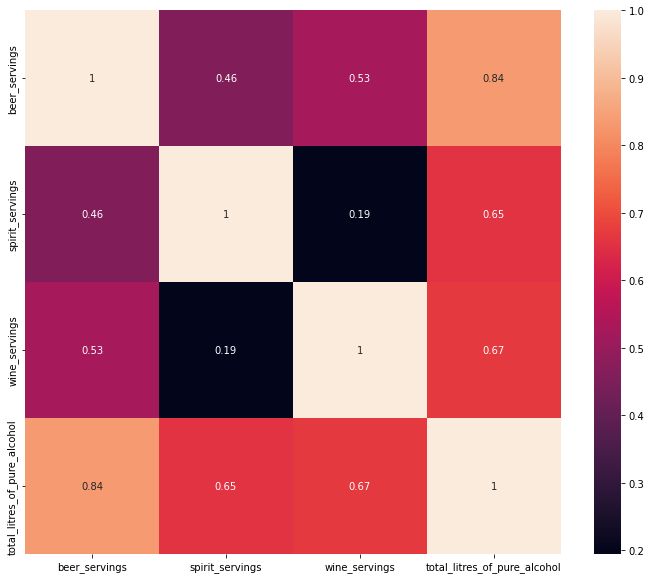

In [155]:
# 3. 행렬 히트맵을 시각화 한다. 
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(drink_heatmap, annot=True)
plt.show()

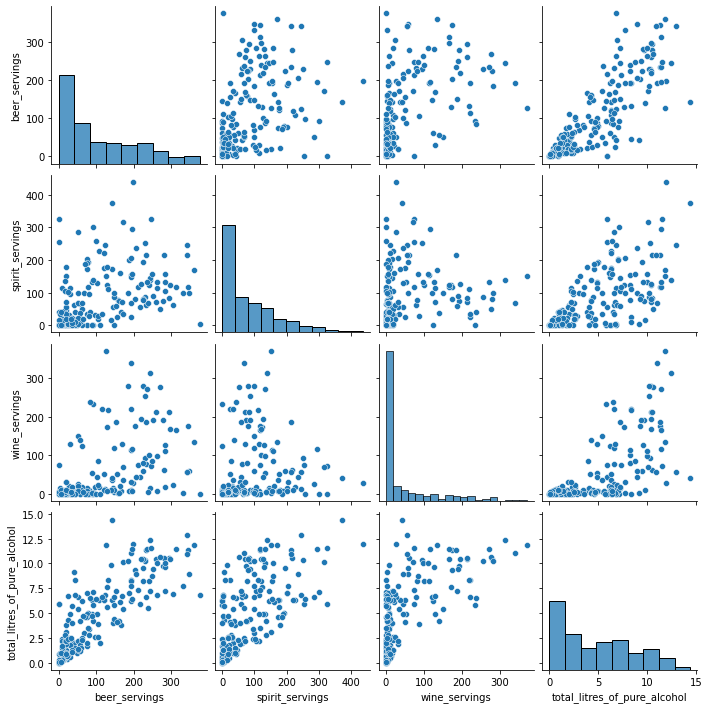

In [156]:
#4 'beer_servings', 'spirit_servings', 'wine_servings', 'total_litres_of_pure_alcohol' 컬럼별 산점도 그래프를 표시한다. 
import pandas as pd

import seaborn as sns
sns.pairplot(drinks) # pairplot 컬럼별로 상관관계 산점도 그리기



In [157]:
drinks.fillna(0)
drinks['rank']=(drinks['beer_servings']+drinks['spirit_servings']+drinks['wine_servings'])/drinks['total_litres_of_pure_alcohol']
drinks['rank']=drinks['rank'].fillna(0)

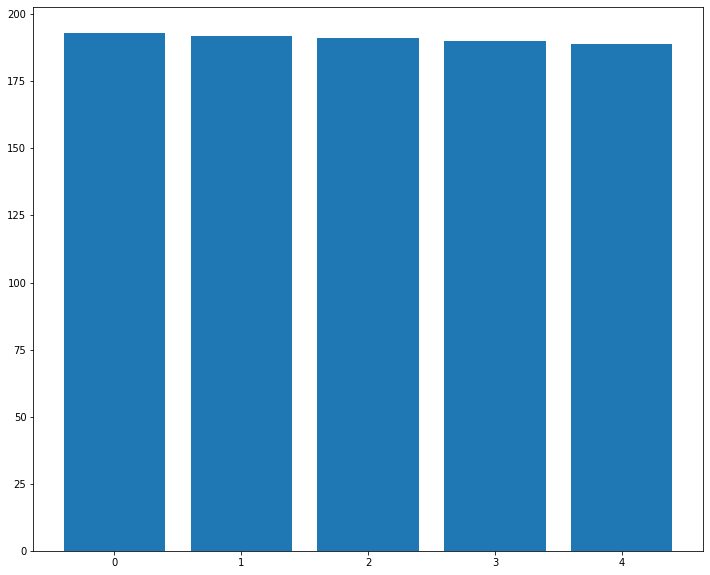

In [158]:
drinks.fillna(0)

drinks['rank_1'] = drinks['rank'].rank(method='first')
drinks_2=drinks[['country','rank_1']].sort_values(by='rank_1',ascending=False)

drinks_2.head(5)
# 빈도수 시각화하기
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(5)
values = [193, 192,191,190,189]

plt.bar(x,values)


plt.show()
# plt.rcParams["figure.figsize"] = (12,10)
# plt.show()

## 3번 문제

1. num_3 폴더의 csv 파일을 데이터프레임으로 불러온다. 
2. uselog를 제외한 3개의 데이터 프레임을 조인 결합 후 결측치를 확인한다. 
3. 고객의 데이터를 'class_name', 'campaign_name', 'gernder', 'is_deleted'별 집계를 출력한다. 
4. 3번 과정과 같은 작업을 2019년 01월 01일부터 최근의 고객 데이터를 출력한다.
5. 월별 'costomer_id' 이용 이력 데이터를 집계하여 출력한다. 
6. 이용 이력 데이터를 통하여 요일별 이용 여부를 계산하고 이용 여부가 4회 이상이면 1 아니면 0인 컬럼을 추가한다.
7. 'end_date' 컬럼을 복사하여 'calc_date' 컬럼을 추가하고 결측데이터를 '20090430'로 변경한다. 
8. 회원의 기간을 계산하여 컬럼을 추가한다. 


#### 1. num_3 폴더의 csv 파일을 데이터프레임으로 불러온다. 

In [159]:
campagin=pd.read_csv('./num_3/campaign_master.csv')
class_=pd.read_csv('./num_3/class_master.csv')
customer=pd.read_csv('./num_3/customer_master.csv')
uselog=pd.read_csv('./num_3/use_log.csv')

#### 2. uselog를 제외한 3개의 데이터 프레임을 조인 결합 후 결측치를 확인한다. 

In [160]:

campagin

,campaign_id,campaign_name
0,CA1,2_일반
1,CA2,0_입회비반액할인
2,CA3,1_입회비무료


In [161]:
class_

,class,class_name,price
0,C01,0_종일,10500
1,C02,1_주간,7500
2,C03,2_야간,6000


In [162]:
customer

,customer_id,name,class,gender,start_date,end_date,campaign_id,is_deleted
0,OA832399,XXXX,C01,F,2015-05-01 00:00:00,NaN,CA1,0
1,PL270116,XXXXX,C01,M,2015-05-01 00:00:00,NaN,CA1,0
2,OA974876,XXXXX,C01,M,2015-05-01 00:00:00,NaN,CA1,0
3,HD024127,XXXXX,C01,F,2015-05-01 00:00:00,NaN,CA1,0
4,HD661448,XXXXX,C03,F,2015-05-01 00:00:00,NaN,CA1,0
...,...,...,...,...,...,...,...,...
4187,HD676663,XXXX,C01,M,2019-03-14 00:00:00,NaN,CA1,0
4188,HD246549,XXXXX,C01,F,2019-03-14 00:00:00,NaN,CA1,0
4189,GD037007,XXXXX,C03,M,2019-03-14 00:00:00,NaN,CA1,0
4190,OA953150,XXXXX,C01,M,2019-03-14 00:00:00,NaN,CA1,0


In [163]:
merge_left = pd.merge(customer,class_, how='outer', on='class')
merge_left['start_date']=pd.to_datetime(merge_left['start_date'])


In [164]:
merge_fin = pd.merge(merge_left,campagin, how='outer', on='campaign_id')
merge_fin.isna().sum()
merge_fin.dtypes

customer_id              object
name                     object
class                    object
gender                   object
start_date       datetime64[ns]
end_date                 object
campaign_id              object
is_deleted                int64
class_name               object
price                     int64
campaign_name            object
dtype: object

In [165]:
merge_fin['end_date']

0                       NaN
1                       NaN
2                       NaN
3                       NaN
4                       NaN
               ...         
4187    2019-02-28 00:00:00
4188                    NaN
4189                    NaN
4190    2019-02-28 00:00:00
4191                    NaN
Name: end_date, Length: 4192, dtype: object

#### 3. 고객의 데이터를 'class_name', 'campaign_name', 'gernder', 'is_deleted'별 집계를 출력한다. 

In [166]:

merge_fin.groupby('class_name').count()['customer_id']

class_name
0_종일    2045
1_주간    1019
2_야간    1128
Name: customer_id, dtype: int64

In [167]:
merge_fin.groupby('campaign_name').count()['customer_id']

campaign_name
0_입회비반액할인     650
1_입회비무료       492
2_일반         3050
Name: customer_id, dtype: int64

In [168]:
merge_fin.groupby('gender').count()['customer_id']

gender
F    1983
M    2209
Name: customer_id, dtype: int64

In [169]:
merge_fin.groupby('is_deleted').count()['customer_id']

is_deleted
0    2842
1    1350
Name: customer_id, dtype: int64

#### 4. 3번 과정과 같은 작업을 2019년 01월 01일부터 최근의 고객 데이터를 출력한다.

In [170]:

merge_fin.loc[merge_fin['start_date'] >= '2019-01-01'].groupby('class_name').count()['customer_id']

class_name
0_종일    98
1_주간    59
2_야간    72
Name: customer_id, dtype: int64

In [171]:
merge_fin.loc[merge_fin['start_date'] >= '2019-01-01'].groupby('campaign_name').count()['customer_id']

campaign_name
2_일반    229
Name: customer_id, dtype: int64

In [172]:
merge_fin.loc[merge_fin['start_date'] >= '2019-01-01'].groupby('gender').count()['customer_id']

gender
F    113
M    116
Name: customer_id, dtype: int64

In [173]:
merge_fin.loc[merge_fin['start_date'] >= '2019-01-01'].groupby('is_deleted').count()['customer_id']

is_deleted
0    215
1     14
Name: customer_id, dtype: int64

#### 5. 월별 'costomer_id' 이용 이력 데이터를 집계하여 출력한다. 

In [178]:
uselog['usedate']=pd.to_datetime(uselog['usedate'])
uselog.dtypes

log_id                 object
customer_id            object
usedate        datetime64[ns]
dtype: object

In [200]:
uselog['month']=uselog['usedate'].dt.strftime('%y%m')
uselog

,log_id,customer_id,usedate,month
0,L00000049012330,AS009373,2018-04-01,1804
1,L00000049012331,AS015315,2018-04-01,1804
2,L00000049012332,AS040841,2018-04-01,1804
3,L00000049012333,AS046594,2018-04-01,1804
4,L00000049012334,AS073285,2018-04-01,1804
...,...,...,...,...
197423,L00000049209753,TS977703,2019-03-31,1903
197424,L00000049209754,TS979550,2019-03-31,1903
197425,L00000049209755,TS995299,2019-03-31,1903
197426,L00000049209756,TS995853,2019-03-31,1903


In [202]:
use_df=uselog.groupby(['month','customer_id']).count()
use_df.head()


log_id  usedate
month customer_id                 
1804  AS002855          4        4
      AS009013          2        2
      AS009373          3        3
      AS015315          6        6
      AS015739          7        7

#### 6. 이용 이력 데이터를 통하여 요일별 이용 여부를 계산하고 이용 여부가 4회 이상이면 1 아니면 0인 컬럼을 추가한다.


In [223]:
a=np.arange(1,197429)
b=a.tolist()
uselog['day']=b
dateDict={0:'월요일',1:'화요일',2:'수요일',3:'목요일',4:'금요일',5:'토요일',6:'일요일'}
for i in range(len(uselog['usedate'])):
    uselog['day'][i]=dateDict[uselog['usedate'][i].weekday()]
    


C:\Users\jangd\AppData\Local\Temp\ipykernel_22636\480505934.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uselog['day'][i]=dateDict[uselog['usedate'][i].weekday()]


,log_id,customer_id,usedate,month,day
0,L00000049012330,AS009373,2018-04-01,1804,일요일
1,L00000049012331,AS015315,2018-04-01,1804,일요일
2,L00000049012332,AS040841,2018-04-01,1804,일요일
3,L00000049012333,AS046594,2018-04-01,1804,일요일
4,L00000049012334,AS073285,2018-04-01,1804,일요일
...,...,...,...,...,...
197423,L00000049209753,TS977703,2019-03-31,1903,일요일
197424,L00000049209754,TS979550,2019-03-31,1903,일요일
197425,L00000049209755,TS995299,2019-03-31,1903,일요일
197426,L00000049209756,TS995853,2019-03-31,1903,일요일


In [269]:
# if 
uselog_count=pd.DataFrame(uselog.groupby(['customer_id','day']).count()['usedate'])
# uselog_count.columns=['count']
a=np.arange(1,26048)
b=a.tolist()
uselog_count['count_1']=b

for i in range(len(b)):
    if uselog_count['usedate'][i]>=4:
        uselog_count['count_1'][i]=1
    else:
        uselog_count['count_1'][i]=0
uselog_count

usedate  count_1
customer_id day                  
AS002855    금요일        1        0
            목요일        5        1
            수요일        3        0
            월요일        2        0
            일요일        5        1
...                  ...      ...
TS999855    수요일        1        0
            월요일        1        0
            일요일        1        0
            토요일       45        1
            화요일        2        0

[26047 rows x 2 columns]

#### 7. 'end_date' 컬럼을 복사하여 'calc_date' 컬럼을 추가하고 결측데이터를 '20090430'로 변경한다. 



In [270]:
uselog['calc_date']=customer['end_date']
uselog['calc_date']=uselog['calc_date'].fillna('20190430')
uselog['calc_date']=pd.to_datetime(uselog['calc_date'])
uselog

,log_id,customer_id,usedate,month,day,calc_date
0,L00000049012330,AS009373,2018-04-01,1804,일요일,2019-04-30
1,L00000049012331,AS015315,2018-04-01,1804,일요일,2019-04-30
2,L00000049012332,AS040841,2018-04-01,1804,일요일,2019-04-30
3,L00000049012333,AS046594,2018-04-01,1804,일요일,2019-04-30
4,L00000049012334,AS073285,2018-04-01,1804,일요일,2019-04-30
...,...,...,...,...,...,...
197423,L00000049209753,TS977703,2019-03-31,1903,일요일,2019-04-30
197424,L00000049209754,TS979550,2019-03-31,1903,일요일,2019-04-30
197425,L00000049209755,TS995299,2019-03-31,1903,일요일,2019-04-30
197426,L00000049209756,TS995853,2019-03-31,1903,일요일,2019-04-30


#### 8. 회원의 기간을 계산하여 컬럼을 추가한다. 

In [272]:
uselog.dtypes

log_id                 object
customer_id            object
usedate        datetime64[ns]
month                  object
day                    object
calc_date      datetime64[ns]
dtype: object

In [274]:
uselog['period']=uselog['calc_date']-uselog['usedate']
uselog

,log_id,customer_id,usedate,month,day,calc_date,period
0,L00000049012330,AS009373,2018-04-01,1804,일요일,2019-04-30,394 days
1,L00000049012331,AS015315,2018-04-01,1804,일요일,2019-04-30,394 days
2,L00000049012332,AS040841,2018-04-01,1804,일요일,2019-04-30,394 days
3,L00000049012333,AS046594,2018-04-01,1804,일요일,2019-04-30,394 days
4,L00000049012334,AS073285,2018-04-01,1804,일요일,2019-04-30,394 days
...,...,...,...,...,...,...,...
197423,L00000049209753,TS977703,2019-03-31,1903,일요일,2019-04-30,30 days
197424,L00000049209754,TS979550,2019-03-31,1903,일요일,2019-04-30,30 days
197425,L00000049209755,TS995299,2019-03-31,1903,일요일,2019-04-30,30 days
197426,L00000049209756,TS995853,2019-03-31,1903,일요일,2019-04-30,30 days
